## **Library**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.metrics import r2_score, mean_squared_error

import xgboost as xgb
import lightgbm as lgb

## **Load Dataset**

In [3]:
# Load Data
df = pd.read_csv('data/volve_production_data.csv')
df

# Exclude columns
exclude_columns = ['WELL_BORE_CODE', 'NPD_WELL_BORE_CODE', 'NPD_FIELD_CODE', 'NPD_FIELD_NAME', 'NPD_FACILITY_CODE', 'NPD_FACILITY_NAME', 'AVG_ANNULUS_PRESS', 'AVG_CHOKE_SIZE_P', 'Faktor Pembagi', 'BORE_WI_VOL']
df = df.drop(columns=exclude_columns)
df.head()

,DATEPRD,NPD_WELL_BORE_NAME,ON_STREAM_HRS,AVG_DOWNHOLE_PRESSURE,AVG_DOWNHOLE_TEMPERATURE,AVG_DP_TUBING,AVG Choke size,AVG_WHP_P,AVG_WHT_P,DP_CHOKE_SIZE,BORE_OIL_VOL,BORE_GAS_VOL,BORE_WAT_VOL,FLOW_KIND,WELL_TYPE
0,2014-04-07,15/9-F-1 C,0.0,0.00000,0.00000,0.00000,0.000000,0.00000,0.00000,0.00000,0.0,0.0,0.0,production,WI
1,2014-04-08,15/9-F-1 C,0.0,NaN,NaN,NaN,0.010031,0.00000,0.00000,0.00000,0.0,0.0,0.0,production,OP
2,2014-04-09,15/9-F-1 C,0.0,NaN,NaN,NaN,0.009790,0.00000,0.00000,0.00000,0.0,0.0,0.0,production,OP
3,2014-04-10,15/9-F-1 C,0.0,NaN,NaN,NaN,0.005458,0.00000,0.00000,0.00000,0.0,0.0,0.0,production,OP
4,2014-04-11,15/9-F-1 C,0.0,310.37614,96.87589,277.27826,0.012160,33.09788,10.47992,33.07195,0.0,0.0,0.0,production,OP


## **EDA**

In [4]:
df.isnull().sum()

DATEPRD                        0
NPD_WELL_BORE_NAME             0
ON_STREAM_HRS                285
AVG_DOWNHOLE_PRESSURE       6654
AVG_DOWNHOLE_TEMPERATURE    6654
AVG_DP_TUBING               6654
AVG Choke size                 0
AVG_WHP_P                   6479
AVG_WHT_P                   6488
DP_CHOKE_SIZE                294
BORE_OIL_VOL                6473
BORE_GAS_VOL                6473
BORE_WAT_VOL                6473
FLOW_KIND                      0
WELL_TYPE                      0
dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15634 entries, 0 to 15633
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   DATEPRD                   15634 non-null  object 
 1   NPD_WELL_BORE_NAME        15634 non-null  object 
 2   ON_STREAM_HRS             15349 non-null  float64
 3   AVG_DOWNHOLE_PRESSURE     8980 non-null   float64
 4   AVG_DOWNHOLE_TEMPERATURE  8980 non-null   float64
 5   AVG_DP_TUBING             8980 non-null   float64
 6   AVG Choke size            15634 non-null  float64
 7   AVG_WHP_P                 9155 non-null   float64
 8   AVG_WHT_P                 9146 non-null   float64
 9   DP_CHOKE_SIZE             15340 non-null  float64
 10  BORE_OIL_VOL              9161 non-null   float64
 11  BORE_GAS_VOL              9161 non-null   float64
 12  BORE_WAT_VOL              9161 non-null   float64
 13  FLOW_KIND                 15634 non-null  object 
 14  WELL_T

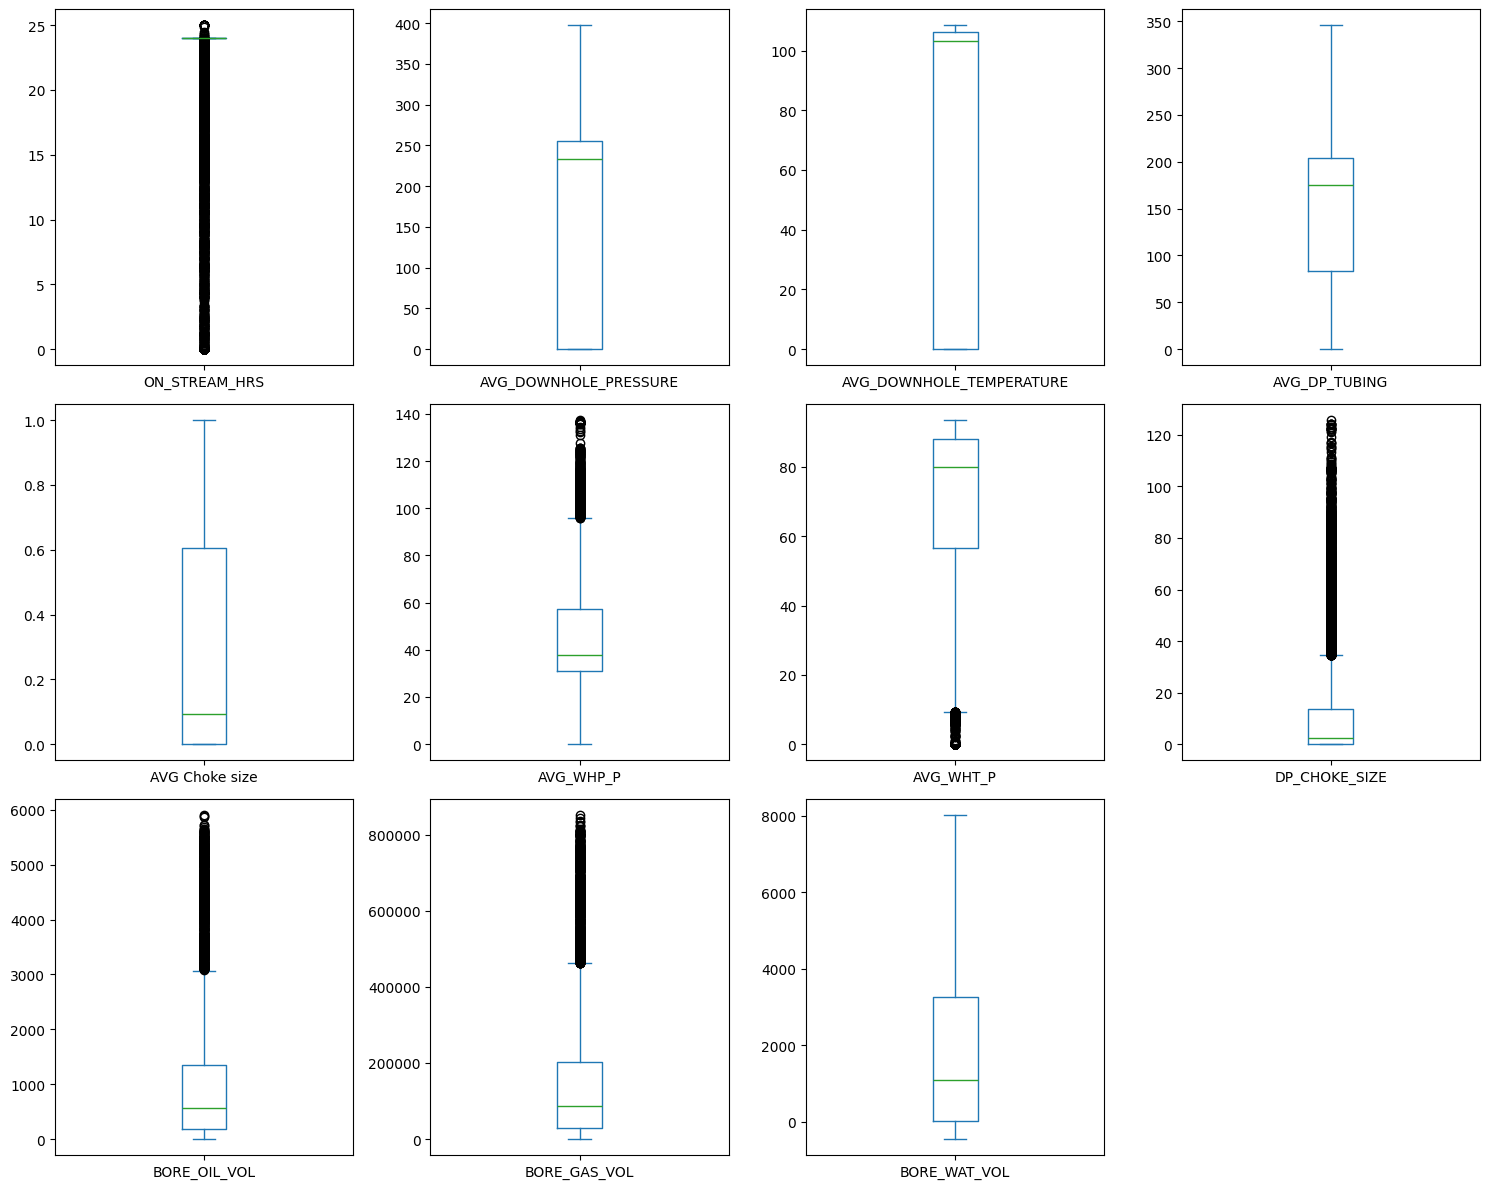

In [6]:
df_numerik = df.select_dtypes(include=['float64'])

jumlah_kolom = len(df_numerik.columns)

kolom_grid = 4
baris_grid = math.ceil(jumlah_kolom / kolom_grid) 

df_numerik.plot(
    kind='box', 
    subplots=True, 
    layout=(baris_grid, kolom_grid), 
    figsize=(15, 4 * baris_grid), 
    sharey=False 
)

plt.tight_layout()

plt.show()

## **Preprocessing**

In [28]:
df['NPD_WELL_BORE_NAME'].unique()

array(['15/9-F-1 C', '15/9-F-11', '15/9-F-12', '15/9-F-14', '15/9-F-15 D',
       '15/9-F-5'], dtype=object)

In [7]:
print(len(df))

15634


In [8]:
df['WELL_TYPE'].unique()

array(['WI', 'OP'], dtype=object)

In [9]:
# Drop row kondisi tertentu

# BORE_OIL_VOL > 0
df = df[df['BORE_OIL_VOL'] > 0]

# FLOW_KIND = 'production'
df = df[df['FLOW_KIND'] == 'production']

# WELL_TYPE = 'OP'
df = df[df['WELL_TYPE'] == 'OP']

In [10]:
print(len(df))

7999


In [11]:
# Standarasasi Format Date
df['DATEPRD'] = pd.to_datetime(df['DATEPRD'], format='%Y-%m-%d')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7999 entries, 15 to 15610
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   DATEPRD                   7999 non-null   datetime64[ns]
 1   NPD_WELL_BORE_NAME        7999 non-null   object        
 2   ON_STREAM_HRS             7999 non-null   float64       
 3   AVG_DOWNHOLE_PRESSURE     7863 non-null   float64       
 4   AVG_DOWNHOLE_TEMPERATURE  7863 non-null   float64       
 5   AVG_DP_TUBING             7863 non-null   float64       
 6   AVG Choke size            7999 non-null   float64       
 7   AVG_WHP_P                 7996 non-null   float64       
 8   AVG_WHT_P                 7996 non-null   float64       
 9   DP_CHOKE_SIZE             7996 non-null   float64       
 10  BORE_OIL_VOL              7999 non-null   float64       
 11  BORE_GAS_VOL              7999 non-null   float64       
 12  BORE_WAT_VOL           

In [12]:
df.isnull().sum()

DATEPRD                       0
NPD_WELL_BORE_NAME            0
ON_STREAM_HRS                 0
AVG_DOWNHOLE_PRESSURE       136
AVG_DOWNHOLE_TEMPERATURE    136
AVG_DP_TUBING               136
AVG Choke size                0
AVG_WHP_P                     3
AVG_WHT_P                     3
DP_CHOKE_SIZE                 3
BORE_OIL_VOL                  0
BORE_GAS_VOL                  0
BORE_WAT_VOL                  0
FLOW_KIND                     0
WELL_TYPE                     0
dtype: int64

## **Feature Engineering**

In [13]:
# Penambahan kolom baru untuk analisis lebih lanjut

# Water Cut
df['WAT_CUT'] = df['BORE_WAT_VOL'] / (df['BORE_OIL_VOL'] + df['BORE_WAT_VOL'])

# Oil Cut
df['OIL_CUT'] = df['BORE_OIL_VOL'] / (df['BORE_OIL_VOL'] + df['BORE_WAT_VOL'])

## **Feature Selection**

In [14]:
# Variabel yang akan digunakan untuk analisis lebih lanjut

var = ['AVG Choke size', 'DP_CHOKE_SIZE', 'ON_STREAM_HRS', 'AVG_DP_TUBING', 'AVG_DOWNHOLE_PRESSURE', 'AVG_DOWNHOLE_TEMPERATURE', 'AVG_WHP_P', 'AVG_WHT_P']

X = df[var]
y_oil = df["BORE_OIL_VOL"]
y_water = df["BORE_WAT_VOL"]


In [15]:
# Split Dataset

X_train, X_test, y_oil_train, y_oil_test = train_test_split(X, y_oil, test_size=0.2, random_state=42)

X_train, X_test, y_water_train, y_water_test = train_test_split(X, y_water, test_size=0.2, random_state=42)


In [16]:
# Standarisasi
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

## **Modelling**

> XGBoost

In [17]:
# Training Model Oil
model_oil_xgb = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

model_oil_xgb.fit(X_train, y_oil_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [18]:
# Training Model Water
model_water_xgb = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

model_water_xgb.fit(X_train, y_water_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [19]:
# Prediction
oil_pred_xgb = model_oil_xgb.predict(X_test)
water_pred_xgb = model_water_xgb.predict(X_test)

In [20]:
# Evaluasi Model Oil
print("XGBoost Oil R2:", r2_score(y_oil_test, oil_pred_xgb))
print("XGBoost Oil RMSE:", np.sqrt(mean_squared_error(y_oil_test, oil_pred_xgb)))

# Evaluasi Model Water
print("XGBoost Water R2:", r2_score(y_water_test, water_pred_xgb))
print("XGBoost Water RMSE:", np.sqrt(mean_squared_error(y_water_test, water_pred_xgb)))

print(df["BORE_OIL_VOL"].mean())
print(df["BORE_WAT_VOL"].mean())

print(100*np.sqrt(mean_squared_error(y_oil_test, oil_pred_xgb))/df["BORE_OIL_VOL"].mean())
print(100*np.sqrt(mean_squared_error(y_water_test, water_pred_xgb))/df["BORE_WAT_VOL"].mean())

XGBoost Oil R2: 0.9846512607553589
XGBoost Oil RMSE: 165.00662589542947
XGBoost Water R2: 0.9774936952849315
XGBoost Water RMSE: 251.74992113244102
1254.3856394549318
1914.9424265533191
13.154377785058971
13.146605226432971


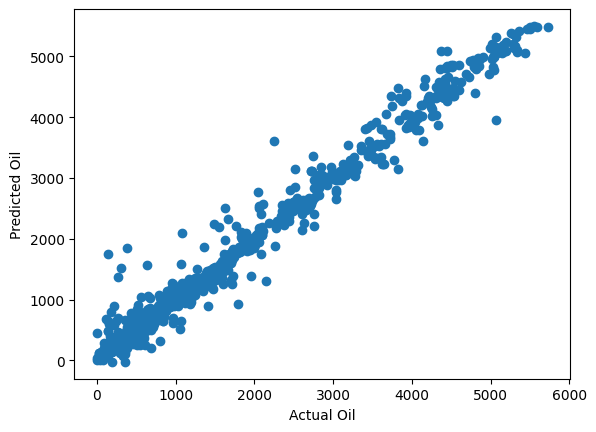

In [21]:
plt.scatter(y_oil_test, oil_pred_xgb)
plt.xlabel("Actual Oil")
plt.ylabel("Predicted Oil")
plt.show()

## **Optimization**

In [22]:
sample = X_test.iloc[0:5].copy()

In [23]:
df['AVG Choke size'].min()

np.float64(0.006)

In [24]:
choke_range = np.arange(0.006, 1, 0.01)

In [29]:
# Loop sample

results_all = []\

for i in range(len(sample)):
    
    well = sample.iloc[i].copy()
    
    results = []

    for choke in choke_range:
        
        well["AVG Choke size"] = choke
        
        well_df = pd.DataFrame([well])
        
        oil_pred = model_oil_xgb.predict(well_df)[0]
        water_pred = model_water_xgb.predict(well_df)[0]
        
        oilcut = oil_pred / (oil_pred + water_pred)
        watercut = water_pred / (oil_pred + water_pred)
        
        results.append([choke, oil_pred, water_pred, oilcut, watercut])
        
    opt_df = pd.DataFrame(results, columns=[
        "Choke",
        "Oil",
        "Water",
        "OilCut",
        "WaterCut"
        # "Score"
    ])
    
    # best = opt_df.loc[opt_df["OilCut"].idxmax()]
    best = opt_df.loc[opt_df["WaterCut"].idxmax()]
    # best = opt_df.loc[opt_df["Score"].idxmax()]
    
    results_all.append(best)
    # choke_pred_list.append(best["Choke"])

In [30]:
optimal_results = pd.DataFrame(results_all)

print(optimal_results)

    Choke         Oil        Water    OilCut  WaterCut
16  0.166  329.329559  1035.336792  0.241326  0.758674
37  0.376  925.686401  2790.489258  0.249097  0.750903
9   0.096   88.189415  3767.207764  0.022874  0.977126
26  0.266   60.751064  2200.135742  0.026870  0.973130
96  0.966  613.338440  1270.327637  0.325609  0.674391


In [27]:
compare_df = pd.DataFrame({
    "Date": df.loc[X_test.index, "DATEPRD"],
    "Oil_Actual": y_oil.loc[X_test.index],
    "Oil_Pred": optimal_results['Oil'],
    "Water_Actual": y_water.loc[X_test.index],
    "Water_Pred": optimal_results['Water'],
    "Choke": df.loc[X_test.index, "AVG Choke size"],
    "Choke_Pred": optimal_results['Choke']  
})

ValueError: cannot reindex on an axis with duplicate labels

In [ ]:
oil_pred = model_oil_xgb.predict(X_test)

r2 = r2_score(y_oil_test, oil_pred)
rmse = np.sqrt(mean_squared_error(y_oil_test, oil_pred))

results = pd.DataFrame({
    "Model": ["XGBoost"],
    "R2 Score": [r2],
    "RMSE": [rmse]
})

results

,Model,R2 Score,RMSE
0,XGBoost,0.984651,165.006626


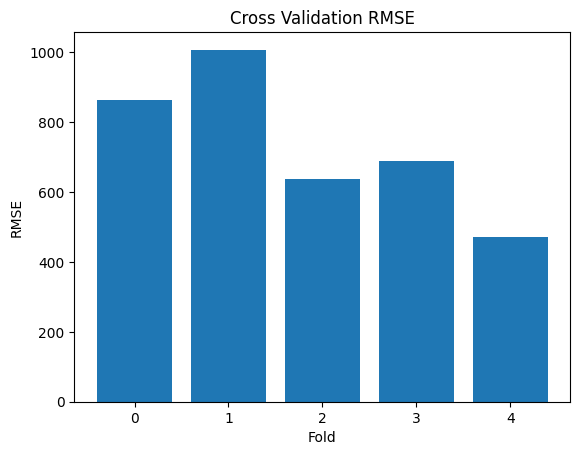

In [ ]:
rmse_scores = np.sqrt(
    -cross_val_score(
        model_oil_xgb,
        X,
        y_oil,
        scoring="neg_mean_squared_error",
        cv=5
    )
)

plt.bar(range(len(rmse_scores)), rmse_scores)

plt.xlabel("Fold")
plt.ylabel("RMSE")
plt.title("Cross Validation RMSE")

plt.show()

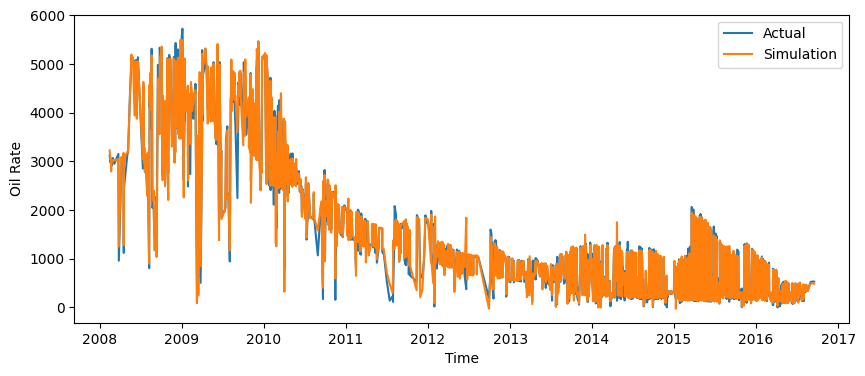

In [ ]:
compare_df = pd.DataFrame({
    "Date": df.loc[X_test.index, "DATEPRD"],
    "Actual": y_oil_test,
    "Simulation": oil_pred
})

compare_df["Date"] = pd.to_datetime(compare_df["Date"])
compare_df = compare_df.sort_values("Date")

plt.figure(figsize=(10,4))

plt.plot(compare_df["Date"], compare_df["Actual"], label="Actual")
plt.plot(compare_df["Date"], compare_df["Simulation"], label="Simulation")

plt.xlabel("Time")
plt.ylabel("Oil Rate")
plt.legend()

plt.show()


In [ ]:
compare_df = pd.DataFrame({
    "Date": df.loc[X_test.index, "DATEPRD"],
    "Oil_Actual": y_oil.loc[X_test.index],
    "Oil_Pred": optimal_results['Oil'],
    "Water_Actual": y_water.loc[X_test.index],
    "Water_Pred": optimal_results['Water'],
    "Choke": df.loc[X_test.index, "AVG Choke size"],
    "Choke_Pred": optimal_results['Choke']  
})

compare_df['Date'] = pd.to_datetime(compare_df['Date'])

tahun = 2014
bulan = 11
df_filter = compare_df[(compare_df['Date'].dt.year == tahun) & (compare_df['Date'].dt.month == bulan)]

df_filter = df_filter.sort_values('Date')

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

axes[0].plot(df_filter['Date'], df_filter['Oil_Actual'], marker='o', color='blue', label='Actual')
axes[0].plot(df_filter['Date'], df_filter['Oil_Pred'], marker='o', color='red', label='Simulation')
axes[0].set_title('Oil Rate vs Time', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Volume')

# --- PLOT 2: WATER RATE ---
axes[1].plot(df_filter['Date'], df_filter['Water_Actual'], marker='o', color='blue', label='Actual')
axes[1].plot(df_filter['Date'], df_filter['Water_Pred'], marker='o', color='red', label='Simulation')
axes[1].set_title('Water Rate vs Time', fontsize=12, fontweight='bold')

# --- PLOT 3: CHOKE SIZE ---
axes[2].plot(df_filter['Date'], df_filter['Choke'], marker='o', color='blue', label='Actual')
axes[2].plot(df_filter['Date'], df_filter['Choke_Pred'], marker='o', color='red', label='Simulation')
axes[2].set_title('Choke Size vs Time', fontsize=12, fontweight='bold')

# 4. Mempercantik Tampilan (Grid, Legend, dan Format Tanggal)
for ax in axes:
    ax.grid(True, linestyle='--', alpha=0.6) # Menambahkan garis bantu/grid tipis
    ax.legend(loc='lower right') # Posisi legend di kanan bawah
    
    # Mengatur format teks sumbu X agar hanya menampilkan Tanggal dan Bulan (Contoh: 05 Nov)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)

plt.tight_layout()
plt.show()

NameError: name 'pd' is not defined